In [1]:
import os 
import pandas as pd

import sys
sys.path.append('../src/utils/')

from utils import read_df

In [2]:
#TASK = "arxiv"
#TASK = "novelpy"
TASK = "cell" 

In [3]:
if TASK == "arxiv":
    TARGET_DATA = "../data/arxiv/arxiv_dataset_all_info.csv"
    TARGET_COLUMN = "novelty"
    ID_COLUMN = "id"
    PREFIX = "arxiv_dataset"
elif TASK == "novelpy":
    TARGET_DATA = None
    TARGET_COLUMN = "score"
    ID_COLUMN = "PMID"
    PREFIX = "novelpy_data"    
elif TASK == "cell":
    TARGET_DATA = None
    TARGET_COLUMN = "wangs_novelty"
    ID_COLUMN = "doi"
    PREFIX = "cell"
else:
    print("UNKNOWN TASK")

In [4]:
if TARGET_DATA is not None:
    df = pd.read_csv(TARGET_DATA)
    df_target = df[[ID_COLUMN, TARGET_COLUMN]].set_index(ID_COLUMN)
else:
    df_target = None

In [5]:
df_results = []

for filename in os.listdir("../results/"):
    if not filename.startswith(PREFIX):
        continue
    filepath = os.path.join("../results", filename)
    print(filepath)
    df = read_df(filepath, index_col=0).groupby(ID_COLUMN).mean()
    filename2 = ".".join(filename.split(".")[:-1])
    df.columns = [f"{filename2[len(PREFIX)+1:-len("_result")]}_score"]
    df_results.append(df)

../results/cell_wangs_novelty_result.parquet
../results/cell_dindex_result.parquet
../results/cell_novelty_sum_result.parquet


In [6]:
if df_target is not None:
    df_result = df_target
    start = 0
else:
    df_result = df_results[0]
    start = 1
for df in df_results[start:]:
    df_result = df_result.join(df, how="left")

In [7]:

df_result 

,wangs_novelty_score,dindex_score,novelty_sum_score
doi,,,
10.1016/j.ajodo.2015.07.001,3.98709,NaN,0.0
10.1016/j.cell.2003.08.001,NaN,0.000269,0.0
10.1016/j.cell.2003.08.008,NaN,-0.004322,6.0
10.1016/j.cell.2004.05.001,NaN,-0.002057,4.0
10.1016/j.cell.2004.05.002,NaN,-0.019042,0.0
...,...,...,...
10.1016/s0092-8674(04)00449-0,NaN,-0.013011,5.0
10.1016/s0092-8674(04)00450-7,NaN,-0.002621,5.0
10.1016/s0092-8674(04)00451-9,NaN,-0.006904,5.0


array([[<Axes: title={'center': 'wangs_novelty_score'}>,
        <Axes: title={'center': 'dindex_score'}>],
       [<Axes: title={'center': 'novelty_sum_score'}>, <Axes: >]],
      dtype=object)

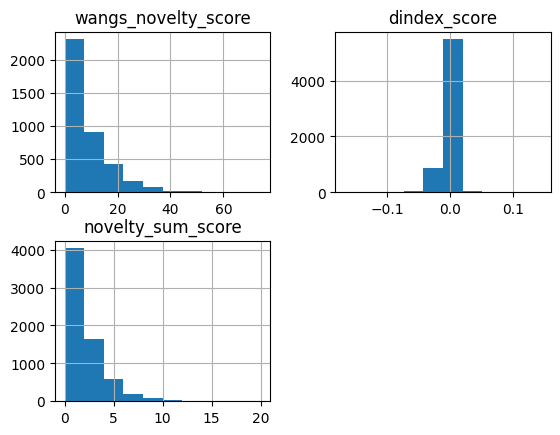

In [8]:
df_result.hist()

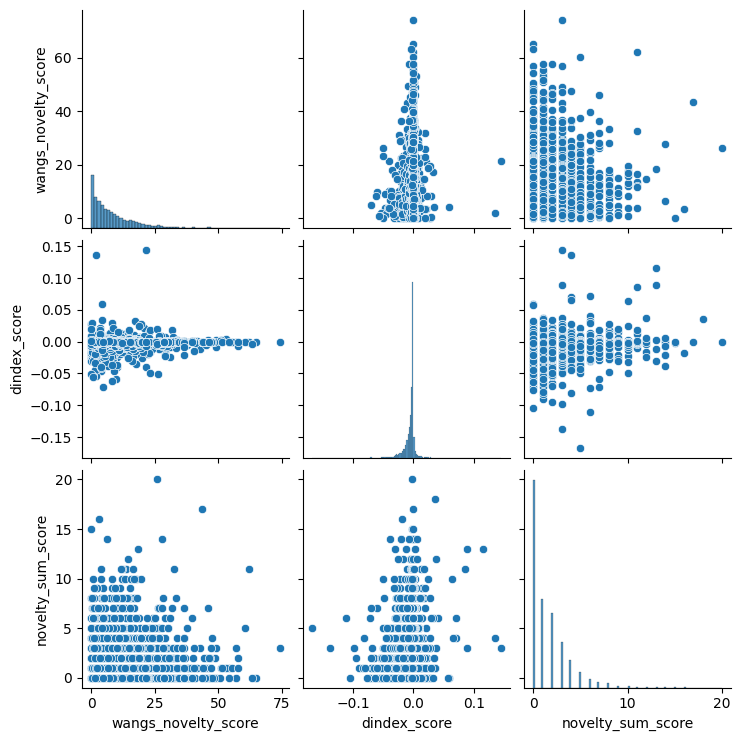

In [9]:
import seaborn as sns
sns.pairplot(df_result)

In [10]:
df_result.corr()

,wangs_novelty_score,dindex_score,novelty_sum_score
wangs_novelty_score,1.000000,0.099854,0.078941
dindex_score,0.099854,1.000000,-0.003760
novelty_sum_score,0.078941,-0.003760,1.000000


In [11]:
df_result.corr(method="spearman")

,wangs_novelty_score,dindex_score,novelty_sum_score
wangs_novelty_score,1.000000,0.192891,0.073447
dindex_score,0.192891,1.000000,-0.064821
novelty_sum_score,0.073447,-0.064821,1.000000
